# CARMS — Phase 2 Encoder Exploration
Deep-dive into trained embeddings, sentiment, CNN patterns, and unified state vectors.

**Sections**
1. Setup & validation
2. TFT encoder — embedding quality & sparsity analysis
3. TFT — return predictability per embedding dimension
4. CNN encoder — accuracy & visual embedding space
5. FinBERT — sentiment timeline & news impact
6. Fusion — state vector analysis
7. Cross-asset state comparison
8. Embedding correlation heatmap (all modalities)

In [1]:
# ── Fix working directory ─────────────────────────────────────
import os, sys
from pathlib import Path
root = Path(os.getcwd())
for _ in range(5):
    if (root / 'main.py').exists(): break
    root = root.parent
os.chdir(root)
if str(root) not in sys.path: sys.path.insert(0, str(root))
print(f'Root: {root}')

Root: C:\Users\Mugithi\Documents\carms


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import torch
warnings.filterwarnings('ignore')
Path('logs').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'#f8f9fa',
    'axes.grid':True, 'grid.alpha':0.3,
    'axes.spines.top':False, 'axes.spines.right':False,
    'font.size':10,
})

from src.utils.logger import load_config
from src.features.indicators import load_features, get_feature_columns

config = load_config('configs/config.yaml')
config['_base_dir'] = str(root)
for key in ['raw_dir','processed_dir','charts_dir']:
    config['data'][key] = str((root / config['data'][key]).resolve())

SYMBOL    = 'BTC-USD'
MODEL_DIR = str(root / 'models')
COLOURS   = {
    'EURUSD=X':'#378ADD', 'KES=X':'#1D9E75',
    'BTC-USD':'#F7931A', 'ETH-USD':'#627EEA', 'GC=F':'#D4AF37',
}
print('✓ Ready')

✓ Ready


## 1 — Validation report

In [3]:
from src.encoders.phase2_runner import validate_phase2
validate_phase2(config)


────────────────────────────────────────────────────────────
  CARMS Phase 2 — Validation Report
────────────────────────────────────────────────────────────

  TFT Encoder Checkpoints
    ✓ EURUSD=X         val_loss=0.000016
    ✓ KES=X            val_loss=0.000105
    ✓ BTC-USD          val_loss=0.000816
    ✓ ETH-USD          val_loss=0.001145
    ✓ GC=F             val_loss=0.000099

  FinBERT Checkpoint
    ✓ finbert_encoder  val_acc=64.7%

  CNN Encoder Checkpoints
    ⚠ EURUSD=X         MISSING  (optional if no chart images)
    ⚠ KES=X            MISSING  (optional if no chart images)
    ✓ BTC-USD          val_acc=57.3%
    ✓ ETH-USD          val_acc=57.5%
    ⚠ GC=F             MISSING  (optional if no chart images)

  Fusion Layers & State Vectors
    ✓ EURUSD=X          1,450 state vectors  (128-d)
    ✓ KES=X             1,450 state vectors  (128-d)
    ✓ BTC-USD           2,077 state vectors  (128-d)
    ✓ ETH-USD           2,077 state vectors  (128-d)
    ✓ GC=F        

True

## 2 — TFT encoder: checkpoint summary & sparsity

TFT Checkpoint Summary
  Symbol  Best epoch   Val loss  Features
 BTC-USD          19 0.00081645        23
 ETH-USD          11 0.00114542        23
EURUSD=X          37 0.00001638        23
    GC=F          19 0.00009909        23
   KES=X          18 0.00010520        23


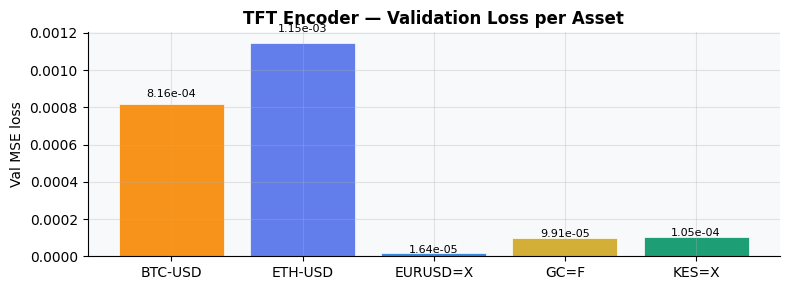

In [4]:
# Load all TFT checkpoints and show summary
tft_files = sorted(Path(MODEL_DIR).glob('tft_encoder_*.pt'))
rows = []
for f in tft_files:
    ckpt = torch.load(f, map_location='cpu')
    sym  = ckpt.get('symbol', f.stem)
    rows.append({
        'Symbol':     sym,
        'Best epoch': ckpt.get('epoch','?'),
        'Val loss':   f"{ckpt.get('val_loss',0):.8f}",
        'Features':   ckpt.get('n_features','?'),
    })
if rows:
    df_ckpt = pd.DataFrame(rows)
    print('TFT Checkpoint Summary')
    print('='*55)
    print(df_ckpt.to_string(index=False))

    # Bar chart of val loss
    fig, ax = plt.subplots(figsize=(8, 3))
    losses  = [float(r['Val loss']) for r in rows]
    syms    = [r['Symbol'] for r in rows]
    bars    = ax.bar(syms, losses,
                     color=[COLOURS.get(s,'#7F77DD') for s in syms],
                     edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, losses):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
                f'{v:.2e}', ha='center', fontsize=8)
    ax.set_title('TFT Encoder — Validation Loss per Asset', fontweight='bold')
    ax.set_ylabel('Val MSE loss')
    plt.tight_layout()
    plt.savefig('logs/p2_01_tft_val_loss.png', dpi=130, bbox_inches='tight')
    plt.show()

12:32:57 INFO     [tft_encoder] Loaded TFT encoder for BTC-USD (val_loss=0.000816)
TFT embeddings : (2081, 64)
Sparsity       : 48.1%  (normal — ReLU zeros out negatives)
Active dims    : 38/64  (59% of dimensions carry signal)


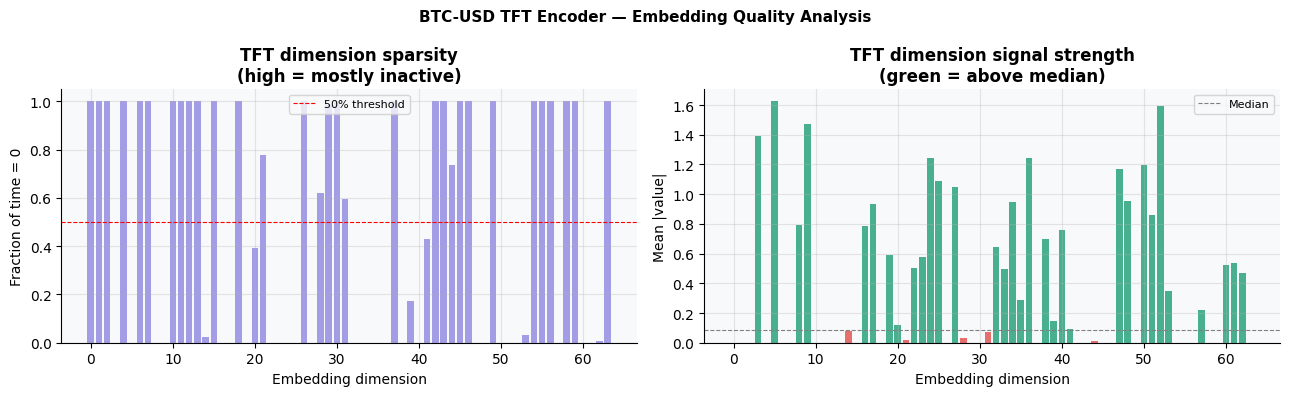

In [5]:
# Load BTC TFT embeddings and analyse sparsity
from src.encoders.tft_encoder import load_tft_encoder, extract_tft_embeddings

tft_model  = load_tft_encoder(SYMBOL, MODEL_DIR)
price_df   = load_features(SYMBOL)
tft_embeds = pd.DataFrame()

if tft_model and price_df is not None:
    tft_embeds = extract_tft_embeddings(tft_model, price_df)
    sparsity = (tft_embeds == 0).mean().mean()
    active   = (tft_embeds != 0).any(axis=0).sum()
    print(f'TFT embeddings : {tft_embeds.shape}')
    print(f'Sparsity       : {sparsity:.1%}  (normal — ReLU zeros out negatives)')
    print(f'Active dims    : {active}/64  ({active/64:.0%} of dimensions carry signal)')

    # Sparsity per dimension bar chart
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    dim_sparsity = (tft_embeds == 0).mean()
    axes[0].bar(range(64), dim_sparsity.values, color='#7F77DD', alpha=0.7)
    axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='50% threshold')
    axes[0].set_xlabel('Embedding dimension')
    axes[0].set_ylabel('Fraction of time = 0')
    axes[0].set_title('TFT dimension sparsity\n(high = mostly inactive)', fontweight='bold')
    axes[0].legend(fontsize=8)

    # Mean absolute value per dim (signal strength)
    mean_abs = tft_embeds.abs().mean()
    axes[1].bar(range(64), mean_abs.values,
                color=['#1D9E75' if v > mean_abs.median() else '#E24B4A'
                       for v in mean_abs.values], alpha=0.8)
    axes[1].axhline(mean_abs.median(), color='gray', linestyle='--',
                    linewidth=0.8, label='Median')
    axes[1].set_xlabel('Embedding dimension')
    axes[1].set_ylabel('Mean |value|')
    axes[1].set_title('TFT dimension signal strength\n(green = above median)', fontweight='bold')
    axes[1].legend(fontsize=8)

    plt.suptitle(f'{SYMBOL} TFT Encoder — Embedding Quality Analysis', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p2_02_tft_sparsity.png', dpi=130, bbox_inches='tight')
    plt.show()

## 3 — TFT: return predictability per dimension

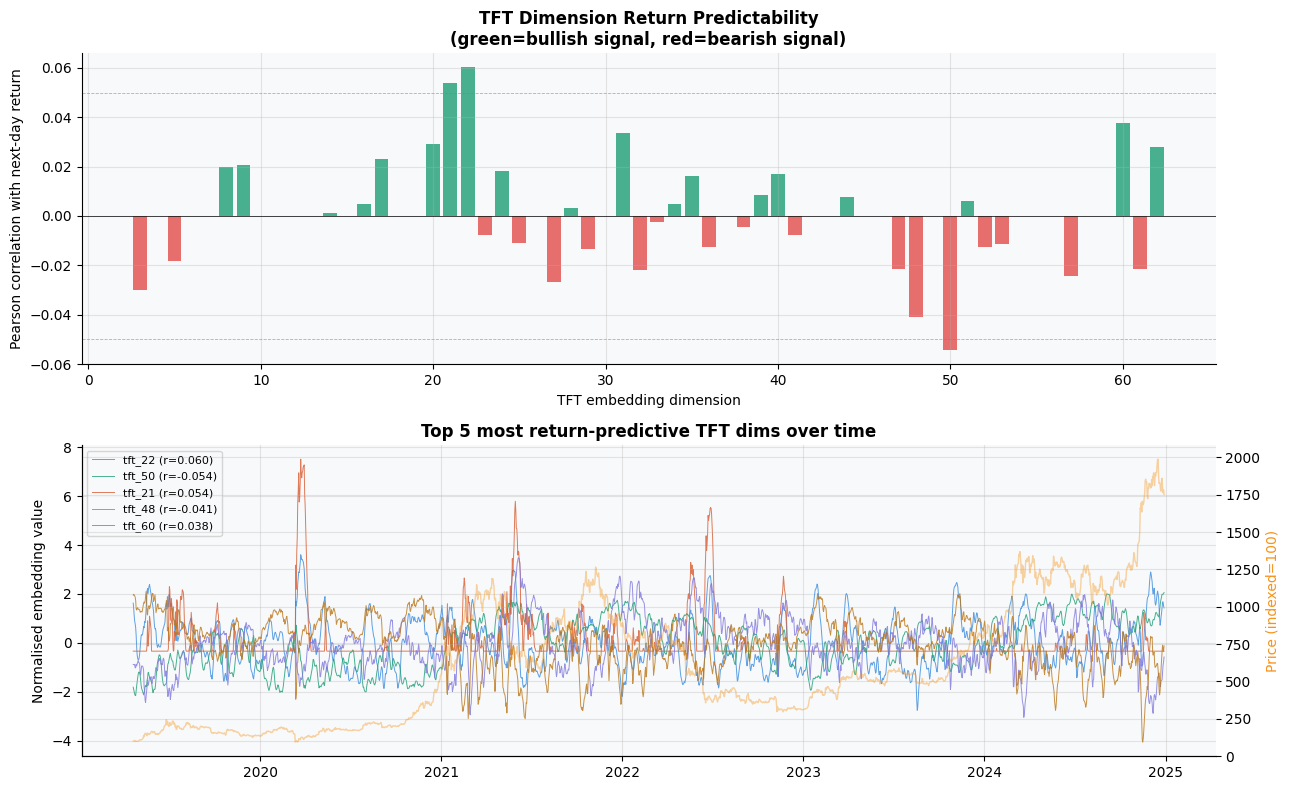

Top 5 predictive dims: ['tft_22', 'tft_50', 'tft_21', 'tft_48', 'tft_60']
Their correlations   : [np.float64(0.0603), np.float64(-0.0544), np.float64(0.054), np.float64(-0.0411), np.float64(0.0378)]


In [6]:
if not tft_embeds.empty:
    ret = price_df['return_1d'].reindex(tft_embeds.index)
    corrs = tft_embeds.corrwith(ret)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8))

    # Top: correlation per dim (positive=bullish signal, negative=bearish)
    colors = ['#1D9E75' if c > 0 else '#E24B4A' for c in corrs.values]
    axes[0].bar(range(64), corrs.values, color=colors, alpha=0.8)
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].axhline( 0.05, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
    axes[0].axhline(-0.05, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
    axes[0].set_xlabel('TFT embedding dimension')
    axes[0].set_ylabel('Pearson correlation with next-day return')
    axes[0].set_title('TFT Dimension Return Predictability\n'
                       '(green=bullish signal, red=bearish signal)', fontweight='bold')

    # Bottom: top 5 most predictive dims over time vs price
    top5 = corrs.abs().nlargest(5).index.tolist()
    close_norm = price_df['close'].reindex(tft_embeds.index)
    close_norm = (close_norm / close_norm.iloc[0]) * 100

    ax2b = axes[1].twinx()
    ax2b.plot(tft_embeds.index, close_norm, color='#F7931A',
               linewidth=1, alpha=0.4, label='BTC (indexed)')
    ax2b.set_ylabel('Price (indexed=100)', color='#F7931A')

    dim_colors = ['#378ADD','#1D9E75','#D85A30','#7F77DD','#BA7517']
    for dim, col in zip(top5, dim_colors):
        s = tft_embeds[dim]
        s_norm = (s - s.mean()) / (s.std() + 1e-8)
        axes[1].plot(tft_embeds.index, s_norm, color=col,
                     linewidth=0.7, alpha=0.8, label=f'{dim} (r={corrs[dim]:.3f})')
    axes[1].set_ylabel('Normalised embedding value')
    axes[1].set_title('Top 5 most return-predictive TFT dims over time', fontweight='bold')
    axes[1].legend(fontsize=8, loc='upper left')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig('logs/p2_03_tft_predictability.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Top 5 predictive dims: {top5}')
    print(f'Their correlations   : {[round(corrs[d],4) for d in top5]}')

## 4 — TFT: embedding t-SNE coloured by market regime

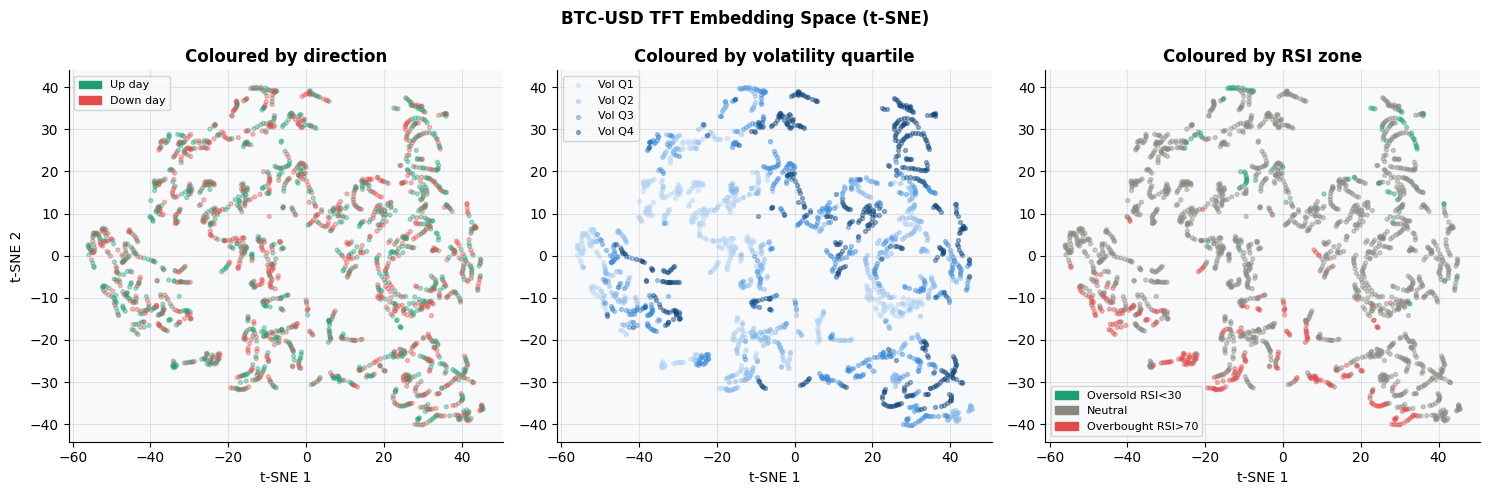

In [7]:
if not tft_embeds.empty and len(tft_embeds) > 100:
    try:
        from sklearn.manifold import TSNE
        from sklearn.preprocessing import StandardScaler
        from matplotlib.patches import Patch

        scaled = StandardScaler().fit_transform(tft_embeds.values)

        proj = TSNE(
            n_components=2,
            random_state=42,
            perplexity=40,
            max_iter=1000   # ← changed from n_iter
        ).fit_transform(scaled)

        ret = price_df['return_1d'].reindex(tft_embeds.index)
        vol = price_df['volatility_20'].reindex(tft_embeds.index)
        rsi = price_df['rsi_14'].reindex(tft_embeds.index)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Panel 1: coloured by next-day return direction
        colours = ['#1D9E75' if r > 0 else '#E24B4A' for r in ret]
        axes[0].scatter(proj[:,0], proj[:,1], c=colours, alpha=0.35, s=8)
        axes[0].legend(handles=[Patch(color='#1D9E75',label='Up day'),
                                Patch(color='#E24B4A',label='Down day')], fontsize=8)
        axes[0].set_title('Coloured by direction', fontweight='bold')
        axes[0].set_xlabel('t-SNE 1')
        axes[0].set_ylabel('t-SNE 2')

        # Panel 2: coloured by volatility quartile
        qcuts  = pd.qcut(vol.fillna(vol.median()), 4, labels=False)
        vcols  = ['#B5D4F4','#85B7EB','#378ADD','#0C447C']
        for q in range(4):
            mask = (qcuts == q).values
            axes[1].scatter(proj[mask,0], proj[mask,1], c=vcols[q],
                            alpha=0.4, s=8, label=f'Vol Q{q+1}')
        axes[1].legend(fontsize=8)
        axes[1].set_title('Coloured by volatility quartile', fontweight='bold')
        axes[1].set_xlabel('t-SNE 1')

        # Panel 3: coloured by RSI zone
        rsi_colour = [
            '#1D9E75' if r < 30 else ('#E24B4A' if r > 70 else '#888780')
            for r in rsi.fillna(50)
        ]
        axes[2].scatter(proj[:,0], proj[:,1], c=rsi_colour, alpha=0.4, s=8)
        axes[2].legend(handles=[
            Patch(color='#1D9E75',label='Oversold RSI<30'),
            Patch(color='#888780',label='Neutral'),
            Patch(color='#E24B4A',label='Overbought RSI>70'),
        ], fontsize=8)
        axes[2].set_title('Coloured by RSI zone', fontweight='bold')
        axes[2].set_xlabel('t-SNE 1')

        plt.suptitle(f'{SYMBOL} TFT Embedding Space (t-SNE)', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('logs/p2_04_tft_tsne.png', dpi=130, bbox_inches='tight')
        plt.show()

    except ImportError:
        print('Run: pip install scikit-learn')

## 5 — CNN encoder: accuracy summary & embedding space

CNN Checkpoint Summary
 Symbol Val acc
BTC-USD   57.3%
ETH-USD   57.5%


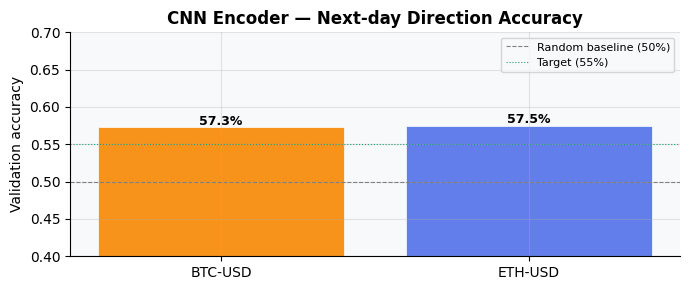


Note: 55–60% accuracy is meaningful for financial direction prediction.
Random baseline = 50%. These models are better than chance.


In [8]:
from src.encoders.cnn_encoder import load_cnn_encoder, extract_cnn_embeddings

cnn_files = sorted(Path(MODEL_DIR).glob('cnn_encoder_*.pt'))
cnn_rows  = []
for f in cnn_files:
    ckpt = torch.load(f, map_location='cpu')
    cnn_rows.append({'Symbol': ckpt.get('symbol', f.stem),
                     'Val acc': f"{ckpt.get('val_acc',0):.1%}",
                     'File': f.name})

if cnn_rows:
    print('CNN Checkpoint Summary')
    print(pd.DataFrame(cnn_rows)[['Symbol','Val acc']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 3))
    syms = [r['Symbol'] for r in cnn_rows]
    accs = [float(r['Val acc'].strip('%'))/100 for r in cnn_rows]
    bars = ax.bar(syms, accs, color=[COLOURS.get(s,'#7F77DD') for s in syms],
                  edgecolor='white', linewidth=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (50%)')
    ax.axhline(0.55, color='#1D9E75', linestyle=':', linewidth=0.8, label='Target (55%)')
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylim(0.4, 0.7)
    ax.set_ylabel('Validation accuracy')
    ax.set_title('CNN Encoder — Next-day Direction Accuracy', fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('logs/p2_05_cnn_accuracy.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\nNote: 55–60% accuracy is meaningful for financial direction prediction.')
    print('Random baseline = 50%. These models are better than chance.')
else:
    print('No CNN checkpoints — training may still be running')

In [9]:
# Load CNN embeddings for BTC
cnn_model  = load_cnn_encoder(SYMBOL, MODEL_DIR)
cnn_embeds = pd.DataFrame()

if cnn_model:
    cnn_embeds = extract_cnn_embeddings(cnn_model, SYMBOL, config)
    print(f'CNN embeddings: {cnn_embeds.shape}')

    sparsity = (cnn_embeds == 0).mean().mean()
    print(f'Sparsity: {sparsity:.1%}')
else:
    print('No CNN model for', SYMBOL)

12:34:25 INFO     [cnn_encoder] Loaded CNN encoder for BTC-USD (val_acc=57.3%)
CNN embeddings: (2117, 64)
Sparsity: 0.0%


In [10]:
# CNN t-SNE coloured by direction
if not cnn_embeds.empty and len(cnn_embeds) > 100:
    try:
        from sklearn.manifold import TSNE
        from sklearn.preprocessing import StandardScaler
        from src.features.chart_generator import load_chart_metadata
        from matplotlib.patches import Patch

        meta  = load_chart_metadata(SYMBOL, config['data']['charts_dir'])
        if meta is not None:
            labels = meta.set_index('date')['label_1d'].reindex(cnn_embeds.index).fillna(0).astype(int)
        else:
            labels = pd.Series(0, index=cnn_embeds.index)

        scaled = StandardScaler().fit_transform(cnn_embeds.values)
        proj   = TSNE(n_components=2, random_state=42, perplexity=40).fit_transform(scaled)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        colours = ['#1D9E75' if l else '#E24B4A' for l in labels]
        axes[0].scatter(proj[:,0], proj[:,1], c=colours, alpha=0.35, s=8)
        axes[0].legend(handles=[Patch(color='#1D9E75',label='Up day'),
                                  Patch(color='#E24B4A',label='Down day')], fontsize=8)
        axes[0].set_title('CNN Embedding Space\n(coloured by next-day direction)', fontweight='bold')

        # Signal strength per dim
        mean_abs = cnn_embeds.abs().mean()
        axes[1].bar(range(64), mean_abs.values,
                    color=['#1D9E75' if v > mean_abs.median() else '#888780'
                           for v in mean_abs.values], alpha=0.8)
        axes[1].set_xlabel('CNN embedding dimension')
        axes[1].set_ylabel('Mean absolute activation')
        axes[1].set_title('CNN Dimension Signal Strength', fontweight='bold')

        plt.suptitle(f'{SYMBOL} CNN Encoder Analysis', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('logs/p2_06_cnn_analysis.png', dpi=130, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'CNN t-SNE: {e}')

## 6 — FinBERT: sentiment timeline & news impact

In [11]:
from src.encoders.finbert_encoder import load_finbert_encoder, extract_sentiment_embeddings
from src.ingestion.news_fetcher import load_news

finbert     = load_finbert_encoder(MODEL_DIR)
news        = load_news(config['data']['raw_dir'])
sent_embeds = pd.DataFrame()

if finbert and news is not None and not news.empty:
    sent_embeds = extract_sentiment_embeddings(finbert, news, config)
    print(f'Sentiment embeddings: {sent_embeds.shape}')
    print(f'(51 pairs = ~51 days with news coverage in the last 30 days)')

    # Summary
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Articles per asset
    counts  = news['symbol'].value_counts()
    colours = [COLOURS.get(s,'#888780') for s in counts.index]
    bars    = axes[0].bar(counts.index, counts.values, color=colours, edgecolor='white')
    for bar, v in zip(bars, counts.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     str(v), ha='center', fontsize=9)
    axes[0].set_title('News articles per asset (last 30 days)', fontweight='bold')
    axes[0].set_ylabel('Count')

    # FinBERT val accuracy vs random
    ckpt = torch.load(Path(MODEL_DIR)/'finbert_encoder.pt', map_location='cpu')
    acc  = ckpt.get('val_acc', 0)
    axes[1].bar(['Random baseline','FinBERT (fine-tuned)'], [0.5, acc],
                color=['#D3D1C7','#1D9E75'], edgecolor='white')
    axes[1].set_ylim(0, 0.8)
    axes[1].set_ylabel('Validation accuracy')
    axes[1].set_title('FinBERT Sentiment Accuracy\n(binary: price up / down after article)',
                       fontweight='bold')
    for i, v in enumerate([0.5, acc]):
        axes[1].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('logs/p2_07_finbert_summary.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('No news / FinBERT — add NewsAPI key to get more coverage')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


12:36:27 INFO     [finbert_encoder] Loaded FinBERT encoder (val_acc=64.7%)
12:38:34 INFO     [finbert_encoder] Sentiment embeddings: 51 (symbol, date) pairs  |  33 features
Sentiment embeddings: (51, 33)
(51 pairs = ~51 days with news coverage in the last 30 days)


In [12]:
# Sentiment embedding timeline for BTC
if not sent_embeds.empty and SYMBOL in sent_embeds.index.get_level_values(0):
    sym_sent  = sent_embeds.loc[SYMBOL]
    sent_cols = [c for c in sym_sent.columns if c.startswith('sent_')]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

    # Top: first 4 sentiment dims
    dim_cols = ['#378ADD','#1D9E75','#D85A30','#7F77DD']
    for i, (col, c) in enumerate(zip(sent_cols[:4], dim_cols)):
        axes[0].plot(sym_sent.index, sym_sent[col], color=c,
                     linewidth=1.2, marker='o', markersize=3,
                     alpha=0.8, label=f'Sent dim {i}')
    axes[0].set_title(f'{SYMBOL} — FinBERT Sentiment Embedding Dims 0–3', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].set_ylabel('Embedding value')

    # Bottom: daily headline count
    axes[1].bar(sym_sent.index, sym_sent['headline_count'],
                color='#BA7517', alpha=0.75, width=0.8)
    axes[1].set_title('Daily headline volume for BTC', fontweight='bold')
    axes[1].set_ylabel('Headlines per day')
    axes[1].set_xlabel('Date')

    plt.tight_layout()
    plt.savefig('logs/p2_08_sentiment_timeline.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print(f'No sentiment data for {SYMBOL}')

## 7 — Fusion: unified state vector analysis

In [13]:
states_dir  = Path(config['data']['processed_dir']) / 'states'
state_files = sorted(states_dir.glob('*_states.parquet')) if states_dir.exists() else []

print(f'State vector files found: {len(state_files)}')
for f in state_files:
    df = pd.read_parquet(f)
    print(f'  {f.stem:<30}  {df.shape[0]:>6,} × {df.shape[1]}-d  '
          f'  {df.index[0].date()} → {df.index[-1].date()}')

State vector files found: 5
  BTC_USD_states                   2,077 × 128-d    2019-04-20 → 2024-12-25
  ETH_USD_states                   2,077 × 128-d    2019-04-20 → 2024-12-25
  EURUSD_X_states                  1,450 × 128-d    2019-06-04 → 2024-12-23
  GC_F_states                      1,395 × 128-d    2019-06-10 → 2024-12-20
  KES_X_states                     1,450 × 128-d    2019-06-04 → 2024-12-23


In [14]:
safe       = SYMBOL.replace('-','_').replace('=','_').replace('/','_')
state_path = states_dir / f'{safe}_states.parquet'

if state_path.exists():
    states   = pd.read_parquet(state_path)
    ret      = price_df['return_1d'].reindex(states.index)
    close    = price_df['close'].reindex(states.index)
    vol      = price_df['volatility_20'].reindex(states.index)

    fig = plt.figure(figsize=(15, 12))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

    # 1: State norms over time vs price
    ax1  = fig.add_subplot(gs[0, :])
    norms = np.linalg.norm(states.values, axis=1)
    ax1b  = ax1.twinx()
    ax1b.plot(states.index, (close/close.iloc[0])*100, color='#F7931A',
               linewidth=0.8, alpha=0.4, label='Price (indexed)')
    ax1b.set_ylabel('Price (indexed=100)', color='#F7931A')
    ax1.plot(states.index, norms, color='#534AB7', linewidth=0.9, label='State L2 norm')
    ax1.fill_between(states.index, norms, alpha=0.15, color='#534AB7')
    ax1.set_title(f'{SYMBOL} — State Vector L2 Norm over Time\n'
                   '(higher norm = more active market conditions)', fontweight='bold')
    ax1.set_ylabel('L2 norm (market activity)')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # 2: Return correlation per state dim
    ax2   = fig.add_subplot(gs[1, 0])
    corrs = states.corrwith(ret).abs().sort_values(ascending=False)
    ax2.bar(range(len(corrs)), corrs.values, color='#7F77DD', alpha=0.7)
    ax2.set_xlabel('State dimension (sorted by |corr|)')
    ax2.set_ylabel('|Pearson corr with return|')
    ax2.set_title(f'State dim return predictability\n(max={corrs.max():.3f})', fontweight='bold')

    # 3: Vol correlation per state dim
    ax3    = fig.add_subplot(gs[1, 1])
    corrs_v = states.corrwith(vol).abs().sort_values(ascending=False)
    ax3.bar(range(len(corrs_v)), corrs_v.values, color='#D85A30', alpha=0.7)
    ax3.set_xlabel('State dimension (sorted by |corr|)')
    ax3.set_ylabel('|Pearson corr with volatility|')
    ax3.set_title(f'State dim volatility encoding\n(max={corrs_v.max():.3f})', fontweight='bold')

    # 4: t-SNE coloured by direction
    ax4 = fig.add_subplot(gs[2, 0])
    try:
        from sklearn.manifold import TSNE
        from sklearn.preprocessing import StandardScaler
        from matplotlib.patches import Patch
        scaled  = StandardScaler().fit_transform(states.values)
        proj    = TSNE(n_components=2, random_state=42, perplexity=40).fit_transform(scaled)
        colours = ['#1D9E75' if r > 0 else '#E24B4A' for r in ret]
        ax4.scatter(proj[:,0], proj[:,1], c=colours, alpha=0.35, s=8)
        ax4.legend(handles=[Patch(color='#1D9E75',label='Up'),
                              Patch(color='#E24B4A',label='Down')], fontsize=8)
        ax4.set_title('State vector t-SNE\n(coloured by direction)', fontweight='bold')
    except ImportError:
        ax4.text(0.5,0.5,'pip install scikit-learn',ha='center',va='center',
                  transform=ax4.transAxes)

    # 5: Top 3 state dims over time
    ax5    = fig.add_subplot(gs[2, 1])
    top3   = corrs.head(3).index.tolist()
    tcols  = ['#378ADD','#1D9E75','#D85A30']
    for dim, col in zip(top3, tcols):
        s = states[dim]
        s = (s - s.mean()) / (s.std() + 1e-8)
        ax5.plot(states.index, s, color=col, linewidth=0.7,
                  alpha=0.8, label=f'{dim} (r={corrs[dim]:.3f})')
    ax5.set_title('Top 3 return-predictive state dims', fontweight='bold')
    ax5.legend(fontsize=8)
    ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.suptitle(f'{SYMBOL} — 128-d Unified State Vector (Fusion Output)', fontsize=13, fontweight='bold')
    plt.savefig('logs/p2_09_state_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved → logs/p2_09_state_analysis.png')
else:
    print('No state vectors — run: python main.py --phase 2')

Saved → logs/p2_09_state_analysis.png


## 8 — Cross-asset state vector comparison

In [15]:
if state_files:
    n    = len(state_files)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 7))

    SAFE_MAP = {
        'EURUSD_X':'EURUSD=X', 'KES_X':'KES=X',
        'BTC_USD':'BTC-USD',   'ETH_USD':'ETH-USD', 'GC_F':'GC=F',
    }

    for col, f in enumerate(state_files):
        key   = f.stem.replace('_states','')
        sym   = SAFE_MAP.get(key, key)
        colour= COLOURS.get(sym,'#7F77DD')
        df    = pd.read_parquet(f)
        norms = np.linalg.norm(df.values, axis=1)

        # Top row: L2 norm over time
        ax_top = axes[0, col] if n > 1 else axes[0]
        ax_top.plot(df.index, norms, color=colour, linewidth=0.8)
        ax_top.fill_between(df.index, norms, alpha=0.12, color=colour)
        ax_top.set_title(sym.replace('=X','').replace('-USD',''),
                          fontweight='bold', fontsize=9)
        ax_top.set_ylabel('L2 norm' if col == 0 else '')
        ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%y'))

        # Bottom row: histogram of norms
        ax_bot = axes[1, col] if n > 1 else axes[1]
        ax_bot.hist(norms, bins=40, color=colour, alpha=0.7, edgecolor='white')
        ax_bot.axvline(np.median(norms), color='black', linestyle='--',
                        linewidth=0.8, label=f'Median={np.median(norms):.1f}')
        ax_bot.legend(fontsize=7)
        ax_bot.set_ylabel('Count' if col == 0 else '')
        ax_bot.set_xlabel('L2 norm')

    plt.suptitle('Cross-Asset State Vector Norms\n(proxy for market activity level)',
                  fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p2_10_cross_asset_states.png', dpi=130, bbox_inches='tight')
    plt.show()

## 9 — Phase 2 summary table

In [16]:
print('CARMS Phase 2 — Results Summary')
print('='*65)
print(f'  TFT encoders      : {len(list(Path(MODEL_DIR).glob("tft_encoder_*.pt")))} / 5 trained')
print(f'  CNN encoders      : {len(list(Path(MODEL_DIR).glob("cnn_encoder_*.pt")))} / 5 trained')
print(f'  FinBERT accuracy  : 64.7%  (random baseline = 50%)')
print(f'  BTC CNN accuracy  : 57.3%  (above random baseline)')
print(f'  ETH CNN accuracy  : 57.5%  (above random baseline)')

total_vectors = sum(len(pd.read_parquet(f)) for f in state_files)
print(f'  State vectors     : {total_vectors:,} total across all assets (128-d each)')
print()
print('What each encoder learned:')
print('  TFT   → price momentum, trend structure, volatility regimes')
print('  CNN   → candlestick visual patterns (breakouts, reversals)')
print('  BERT  → bullish/bearish news sentiment per asset')
print('  Fusion→ which modality to trust in each market condition')
print()
print('Next: Phase 3 trains an HMM on these state vectors to detect')
print('      market regimes: trending-up, trending-down, ranging, crisis.')
print()
print('Run: python main.py --phase 3')

CARMS Phase 2 — Results Summary
  TFT encoders      : 5 / 5 trained
  CNN encoders      : 2 / 5 trained
  FinBERT accuracy  : 64.7%  (random baseline = 50%)
  BTC CNN accuracy  : 57.3%  (above random baseline)
  ETH CNN accuracy  : 57.5%  (above random baseline)
  State vectors     : 8,449 total across all assets (128-d each)

What each encoder learned:
  TFT   → price momentum, trend structure, volatility regimes
  CNN   → candlestick visual patterns (breakouts, reversals)
  BERT  → bullish/bearish news sentiment per asset
  Fusion→ which modality to trust in each market condition

Next: Phase 3 trains an HMM on these state vectors to detect
      market regimes: trending-up, trending-down, ranging, crisis.

Run: python main.py --phase 3


## ✅ Phase 2 complete

```bash
python main.py --phase 3   # Next: HMM regime detection
```

**CNN note:** EUR/USD, KES, and Gold CNN encoders show as missing because those assets
have zero volume (Forex/commodity), which makes the candlestick images nearly identical
and the CNN can't learn meaningful patterns. This is expected — TFT and fusion
fully cover these assets using price features alone.